# 0) Setup

In [17]:
# XTF file 
import torch
from physdnet.xtf_utils import *
import numpy as np 
import matplotlib.pyplot as plt
from physdnet.prep import *
from physdnet.test import *
from physdnet.terrain_mask import *
import pyxtf
from pathlib import Path

xtf_file = r"2025-09-24_09-25-24_0.xtf"
xtf_dir = r"/home/david/Documents/IFRoS/Perception/HoP-SSS-Loop-Closure/data" 

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') # Define GPU device

# For data preparation
segment_size = 2000
overlap_size = 1000
upper_limit = 2 ** 15

# For PhysDNet
weight_path = r'best_model_v610_eagle.pth'     # Select the best weights for inference of PhysDNet
# weight_path = r'best_model_v610_jaguar.pth'
# weight_path = r'best_model_v611_jaguar.pth'

# ----- Group of timestamp A ------
# For inference
output_path_root_A = r"output_i/A"
test_image_path_A = r'output_i/A/images'
test_range_path_A = r'output_i/A/range'
test_altitude_path_A = r'output_i/A/altitude'
output_inf_A = r'output_i/A/visual_test'           # Result saving path after inference

# Directory for rho gray image, MINIMA input
rho_gray_path_A = r"output_i/A_left/visual_test/rho_gray"
mask_path_A = r"output_i/A_left/final_masks"

# For terrain mask generation
altitude_dir_A = r"output_i/A/altitude"
range_dir_A = r"output_i/A/range"
depth_dir_A = r"output_i/A/visual_test/z_gray"                # Predicted height map
height_output_dir_A = r"output_i/A/visual_test/height_visual" # Store the grayscale image of the generated height map and the mask of its understated terrain areas.
output_folder_A = r"output_i/A/visual_test/z_mask"

# ----- Group of timestamp B ------
output_path_root_B = r"output_i/B"
test_image_path_B = r'output_i/B/images'
test_range_path_B = r'output_i/B/range'
test_altitude_path_B = r'output_i/B/altitude'
output_inf_B = r'output_i/B/visual_test'           # Result saving path after inference

# For terrain mask generation
altitude_dir_B = r"output_i/B/altitude"
range_dir_B = r"output_i/B/range"
depth_dir_B = r"output_i/B/visual_test/z_gray"                # Predicted height map
height_output_dir_B = r"output_i/B/visual_test/height_visual" # Store the grayscale image of the generated height map and the mask of its understated terrain areas.
output_folder_B = r"output_i/B/visual_test/z_mask"

# Directory for rho gray image, MINIMA input
rho_gray_path_B = r"output_i/B_left/visual_test/rho_gray"
mask_path_B = r"output_i/B_left/final_masks"

# Desired side
side: str = "left"  # left, right or both joined together

# 1) Define interest time stamps 

In [41]:
timestamp1 = 55200
timestamp2 = 58200

#### Get the valid indices groups

---------------------
FileFormat: 123
SystemType: 1
RecordingProgramName: b'IQUA'
RecordingProgramVersion: b'100'
SonarName: b'ScoutMkII_ros'
SonarType: 44
NoteString: b'Marine Sonic Technology Corp.'
ThisFileName: b'/home/user/logs/mk_ii/2025-09-24_09-25-24_0.xtf'
NavUnits: 3
NumberOfSonarChannels: 2
NumberOfBathymetryChannels: 0
NumberOfSnippetChannels: 0
NumberOfForwardLookArrays: 0
NumberOfEchoStrengthChannels: 0
NumberOfInterferometryChannels: 0
Reserved1: 0
Reserved2: 0
ReferencePointHeight: 0.0
ProjectionType: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
SpheriodType: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
NavigationLatency: 0
OriginY: 0.0
OriginX: 0.0
NavOffsetY: 0.0
NavOffsetX: 0.0
NavOffsetZ: 0.0
NavOffsetYaw: 0.0
MRUOffsetY: 0.0
MRUOffsetX: 0.0
MRUOffsetZ: 0.0
MRUOffsetYaw: 0.0
MRUOffsetPitch: 0.0
MRUOffsetRoll: 0.0
ChanInfo: [<pyxtf.xtf_ctypes.XTFChanInfo object at 0x759a2d2db3d0>, <pyxtf.xtf_ctypes.XTFChanInfo object at 0x759a2d2db450>, <pyxtf.xtf_ctypes.XTFChanInfo object at 0x759a2d2db4

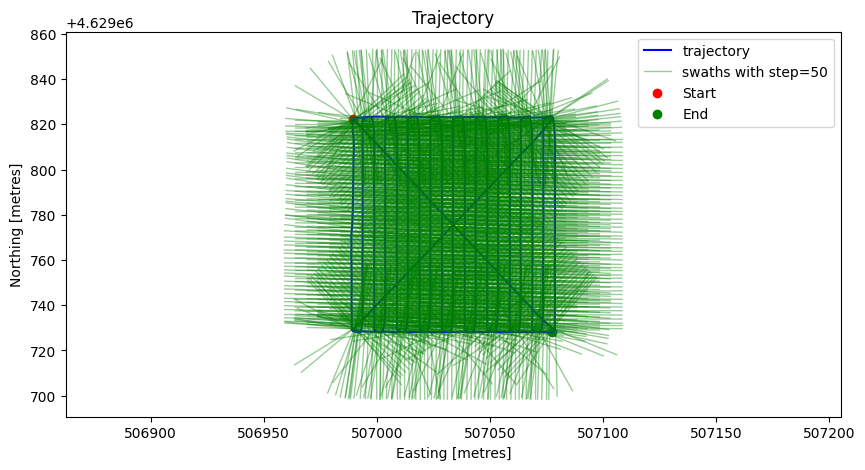

Count of groups:  23


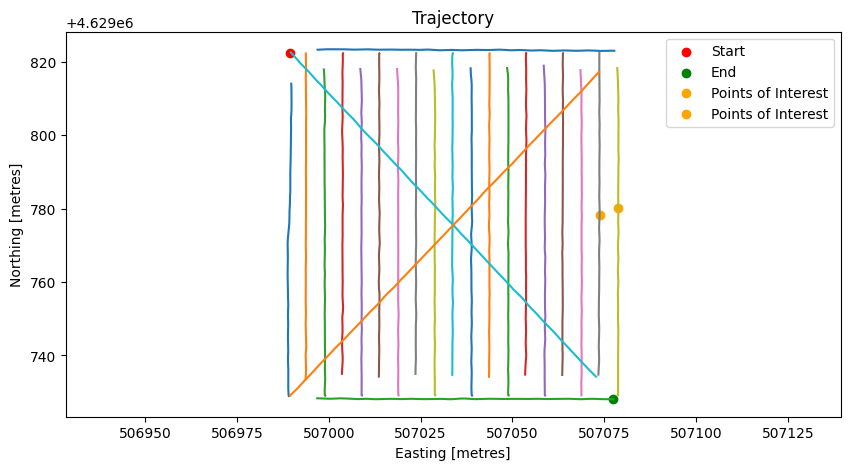

In [42]:

import matplotlib.pyplot as plt 
data_load = load_xtf(r"data/" + xtf_file)
swaths, trajectory, altitude, roll, pitch, yaw = calculate_swath_positions(data_load)

_, ax = plt.subplots(figsize=(10,5))

# Plot trajectory
ax.plot(trajectory[:,0], trajectory[:,1], color="blue", label="trajectory")

# Plot ping lines 
step = 50
for i in range(0, swaths.shape[0], step):
    start_point = swaths[i, 0, :]      
    end_point = swaths[i, -1, :]       
    
    x_vals = [start_point[0], end_point[0]]
    y_vals = [start_point[1], end_point[1]]
    
    if i == 0:
        ax.plot(x_vals, y_vals, color='green', linestyle='-', alpha=0.4, linewidth=1, label=f"swaths with step={step}")
    else:    
        ax.plot(x_vals, y_vals, color='green', linestyle='-', alpha=0.4, linewidth=1)

ax.axis("equal")
ax.set_title("Trajectory")
ax.set_xlabel("Easting [metres]")
ax.set_ylabel("Northing [metres]")
ax.axis("equal")
ax.scatter([trajectory[0,0]], [trajectory[0,1]], label="Start", c="red")
ax.scatter([trajectory[-1,0]], [trajectory[-1,1]], label="End", c="green")
ax.legend()
plt.show()

filter, dy = lowpass_and_derivative_5point(np.arange(len(np.unwrap(yaw)*180/np.pi)), np.unwrap(yaw)*180/np.pi, 0.01)

# Threshold the derivative to find where 
threshold = 0.08
Ids = np.where(np.abs(dy)>threshold)[0]
new_index = range(0, swaths.shape[0],1)
new_index = np.delete(new_index,Ids)

# Detect different groups after removing turns
changes = 1
jumps = np.where(np.diff(new_index) > changes)[0] + 1
groups = np.split(new_index, jumps)

# Preserve only large groups
min_group_size = 29
groups_indices = [g for g in groups if len(g) > min_group_size]

print("Count of groups: ", len(groups_indices))
max_values = [np.max(i) for i in groups_indices]

# Plot the trajectory with different colors for each group
_, ax = plt.subplots(figsize=(10,5))
for i in range(len(groups_indices)):
    minimum = min(groups_indices[i])
    maximum = max(groups_indices[i])
    ax.plot(trajectory[minimum:maximum,0], trajectory[minimum:maximum,1])

ax.axis("equal")
ax.set_title("Trajectory")
ax.set_xlabel("Easting [metres]")
ax.set_ylabel("Northing [metres]")
ax.axis("equal")
ax.scatter([trajectory[0,0]], [trajectory[0,1]], label="Start", c="red")
ax.scatter([trajectory[-1,0]], [trajectory[-1,1]], label="End", c="green")
ax.scatter(trajectory[timestamp1,0], trajectory[timestamp1,1], label="Points of Interest", c="orange")
ax.scatter(trajectory[timestamp2,0], trajectory[timestamp2,1], label="Points of Interest", c="orange")
ax.legend()

plt.show()

#### Check whether the timestamps are valid
#### They have to be within a group and with a low temporal difference

In [43]:
t1_group_idx: bool = None
t2_group_idx: bool = None

# Check all the groups to identify the indices
for i, g in enumerate(groups_indices):
    if timestamp1 in g: t1_group_idx = i
    if timestamp2 in g: t2_group_idx = i

if t1_group_idx is not None and t2_group_idx is not None:
    print(f"Both timestamp1: {timestamp1} and timestamp2: {timestamp2} are valid and belong to the groups. They belong to the groups: {t1_group_idx} and {t2_group_idx} respectively.")
elif t1_group_idx is not None and t2_group_idx is None:
    print(f"WARNING: timestamp1: {timestamp1} is valid, but timestamp2: {timestamp2} is not valid since it corresponds to a turn.")
elif t1_group_idx is None and t2_group_idx is not None:
    print(f"WARNING: timestamp1: {timestamp1} is not valid it corresponds to a turn, but timestamp2: {timestamp2} is valid.")
else:
    print(f"WARNING: Neither timestamp1: {timestamp1} nor timestamp2: {timestamp2} are valid, they correspond to turns.")

Both timestamp1: 55200 and timestamp2: 58200 are valid and belong to the groups. They belong to the groups: 17 and 18 respectively.


# 2) Get the indices for the desired time stamps

#### Extract the indices range for each timestap to generate the corresponding images

In [44]:
# For the first timestamp group
'''
The range of the window should be of size 2000 pings to be compatible with PhysDNet. 
Ideally, the timestamp should be in the middle of the window, but if it is too close to the beginning or the end of the group, it will be accordingly adjusted. 
'''

# Extract the range windows for both timestamps
group1 = groups_indices[t1_group_idx]
group2 = groups_indices[t2_group_idx]

lower1, upper1 = get_range_window(group1, timestamp1)
lower2, upper2 = get_range_window(group2, timestamp2)


Group corresponding to timestamp: 55200 has 2528 pings.
The ideal window for timestamp: 55200 is valid and will be set from 54200.0 to 56200.0.
Group corresponding to timestamp: 58200 has 2570 pings.
The ideal window for timestamp: 58200 is valid and will be set from 57200.0 to 59200.0.


# 3) Prepare the data for PhysDNet and extract pings

In [45]:
packetsA: list[pyxtf.XTFPingHeader] = prepare_data_range(xtf_dir, xtf_file, output_path_root_A, 2000, 1000, 2**15, side="left", data_lower_limit= lower1, data_upper_limit= upper1)
packetsB: list[pyxtf.XTFPingHeader] = prepare_data_range(xtf_dir, xtf_file, output_path_root_B, 2000, 1000, 2**15, side="left", data_lower_limit= lower2, data_upper_limit= upper2)

Processing file: 2025-09-24_09-25-24_0.xtf
	Number of blind bins: 670
Mask calculated!
mask_left: (2000, 2000), mask_right: (2000, 2000)
left channel data shape (2000, 2000)
left channel data shape 4000000
Saved in output_i/A_left/2025-09-24_09-25-24_0.xtf_mask_right.png
2025-09-24_09-25-24_0.xtf: total_rows=2000, segments=1, stride=1000
Processing file: 2025-09-24_09-25-24_0.xtf
	Number of blind bins: 664
Mask calculated!
mask_left: (2000, 2000), mask_right: (2000, 2000)
left channel data shape (2000, 2000)
left channel data shape 4000000
Saved in output_i/B_left/2025-09-24_09-25-24_0.xtf_mask_right.png
2025-09-24_09-25-24_0.xtf: total_rows=2000, segments=1, stride=1000


# 4) Process the data with PhysDNet 

#### Run inference to generate the height, shadow and reflectance imaiges

In [46]:
run_inference(device, test_image_path_A, test_range_path_A, test_altitude_path_A, weight_path, output_inf_A, 'left', prefix="A")
run_inference(device, test_image_path_B, test_range_path_B, test_altitude_path_B, weight_path, output_inf_B, 'left', prefix="B")

Image saved to: output_i/A_left/visual_test/theta/2025-09-24_09-25-24_0.xtf_left_000_theta.png
Image saved to: output_i/A_left/visual_test/z/2025-09-24_09-25-24_0.xtf_left_000_z.png
Image saved to: output_i/A_left/visual_test/path/2025-09-24_09-25-24_0.xtf_left_000_path.png
Image saved to: output_i/A_left/visual_test/rho/2025-09-24_09-25-24_0.xtf_left_000_rho.png
Image saved to: output_i/B_left/visual_test/theta/2025-09-24_09-25-24_0.xtf_left_000_theta.png
Image saved to: output_i/B_left/visual_test/z/2025-09-24_09-25-24_0.xtf_left_000_z.png
Image saved to: output_i/B_left/visual_test/path/2025-09-24_09-25-24_0.xtf_left_000_path.png
Image saved to: output_i/B_left/visual_test/rho/2025-09-24_09-25-24_0.xtf_left_000_rho.png


#### Generate the masks necessary to reject outliers and combine them 

In [47]:
terrain_mask(altitude_dir_A, range_dir_A, depth_dir_A, height_output_dir_A, output_folder_A, "left", prefix="A")
terrain_mask(altitude_dir_B, range_dir_B, depth_dir_B, height_output_dir_B, output_folder_B, "left", prefix="B")

# Combine masks into a single image and reshape if necessary

# FOR IMAGE A
shadow_mask_path_A =  r"output_i/A_left/shadow"
z_mask_path_A =       r"output_i/A_left/visual_test/z_mask"
blind_mask_A =        r"output_i/A_left/2025-09-24_09-25-24_0.xtf_mask_left.png"

# Get all the files
shadow_mask_files_A = [f for f in os.listdir(shadow_mask_path_A) if f.lower().endswith('.png')]
z_mask_files_A = [f for f in os.listdir(z_mask_path_A) if f.lower().endswith('.png')]

# Generate all the masks by combining the shadow mask, z mask, and blind mask
masks_output_A = r"output_i/A_left/final_masks"
os.makedirs(masks_output_A, exist_ok=True)

# FOR IMAGE B
shadow_mask_path_B =  r"output_i/B_left/shadow"
z_mask_path_B =       r"output_i/B_left/visual_test/z_mask"
blind_mask_B =        r"output_i/B_left/2025-09-24_09-25-24_0.xtf_mask_left.png"

# Get all the files
shadow_mask_files_B = [f for f in os.listdir(shadow_mask_path_B) if f.lower().endswith('.png')]
z_mask_files_B = [f for f in os.listdir(z_mask_path_B) if f.lower().endswith('.png')]

# Generate all the masks by combining the shadow mask, z mask, and blind mask
masks_output_B = r"output_i/B_left/final_masks"
os.makedirs(masks_output_B, exist_ok=True)

i = 0
for shadow_file_A, z_mask_file_A, shadow_file_B, z_mask_file_B in zip(shadow_mask_files_A, z_mask_files_A, shadow_mask_files_B, z_mask_files_B):
    shadow_i_path_A = os.path.join(shadow_mask_path_A, shadow_file_A)
    z_i_path_A = os.path.join(z_mask_path_A, z_mask_file_A)
    output_i_A = os.path.join(masks_output_A, f"mask_{i}.png")
    combine_masks(z_i_path_A, shadow_i_path_A, blind_mask_A, output_path=output_i_A)

    shadow_i_path_B = os.path.join(shadow_mask_path_B, shadow_file_B)
    z_i_path_B = os.path.join(z_mask_path_B, z_mask_file_B)
    output_i_B = os.path.join(masks_output_B, f"mask_{i}.png")
    combine_masks(z_i_path_B, shadow_i_path_B, blind_mask_B, output_path=output_i_B)

100%|██████████| 1/1 [00:00<00:00, 47.23it/s]


Processing complete


100%|██████████| 1/1 [00:00<00:00, 116.09it/s]

Processing complete


# 5) Run MINIMA on raw reflectance images in pixel coordinates

Raw matches: 47
After mask filtering: 12
RANSAC inliers: 6
Homography:
 [[ 5.06593994e-01 -3.59048529e-01  5.35098289e+01]
 [ 5.02542558e-02  5.80420255e-01 -6.86754657e+00]
 [-1.70993905e-04 -3.64057508e-03  1.00000000e+00]]


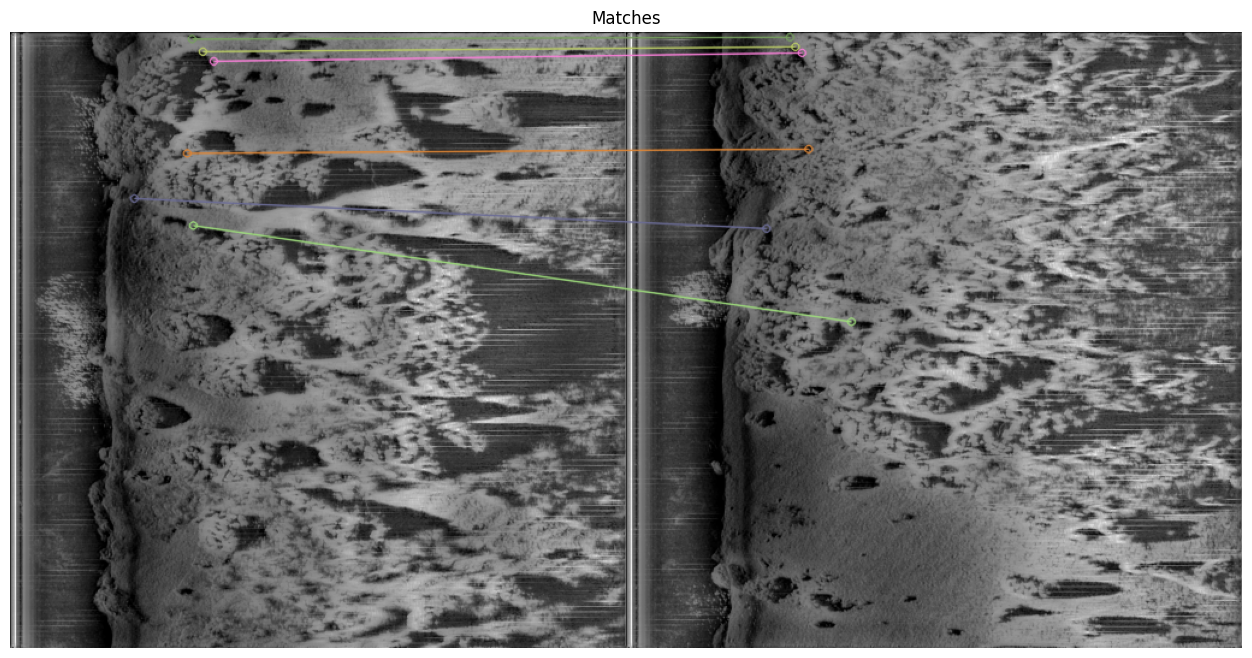

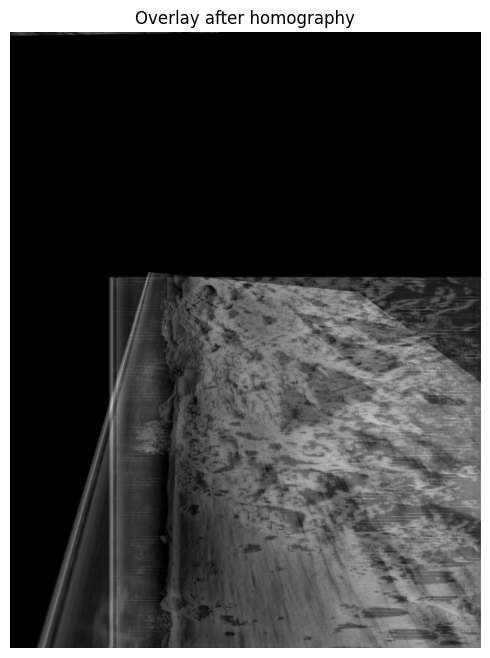

In [48]:
from minima_pipeline import MinimaMatcher, run_pipeline_on_images, draw_matches
import matplotlib.pyplot as plt

# Build matcher for in-memory images
matcher = MinimaMatcher(method="sp_lg", ckpt="MINIMA/weights/minima_lightglue.pth", use_path=False)

# rho_images_A = [f for f in os.listdir(rho_gray_path_A) if f.lower().endswith('.png')].sort(key=lambda s: int(s.split('_')[-3].split('.')[0]))[0]
# rho_images_B = [f for f in os.listdir(rho_gray_path_B) if f.lower().endswith('.png')].sort(key=lambda s: int(s.split('_')[-3].split('.')[0]))[0]

# # Get the first two images, since they are consecutive, there should be a lot of matches
# # These images are then aligned one with another to confirm the homography is correct
# img0 = cv2.imread(os.path.join(rho_gray_path_A, rho_images_A))
# img1 = cv2.imread(os.path.join(rho_gray_path_B, rho_images_B))
img0 = cv2.imread(Path(r"output_i/A_left/visual_test/rho_gray/2025-09-24_09-25-24_0.xtf_left_000_rho_gray.png"))
img1 = cv2.imread(Path(r"output_i/B_left/visual_test/rho_gray/2025-09-24_09-25-24_0.xtf_left_000_rho_gray.png"))

# Your binary masks, same size as each image
# mask_A = [f for f in os.listdir(mask_path_A) if f.lower().endswith('.png')].sort(key=lambda s: int(s.split('_')[-1].split('.')[0]))[0]
# mask_B = [f for f in os.listdir(mask_path_B) if f.lower().endswith('.png')].sort(key=lambda s: int(s.split('_')[-1].split('.')[0]))[0]
# mask0 = cv2.imread(os.path.join(mask_path_A, mask_A), cv2.IMREAD_GRAYSCALE)
# mask1 = cv2.imread(os.path.join(mask_path_B, mask_B), cv2.IMREAD_GRAYSCALE)
mask0 = cv2.imread(Path(r"output_i/B_left/final_masks/mask_0.png"))
mask1 = cv2.imread(Path(r"output_i/A_left/final_masks/mask_0.png"))

# Get the result from the matcher between the two images
result = run_pipeline_on_images(
    matcher,
    img0,
    img1,
    mask0=mask0,
    mask1=mask1,
    ransac_reproj_threshold=8.0,
    ransac_max_iters=10_000,
    ransac_confidence=0.995
)

# Draws the matches
vis = draw_matches(img0, img1, result.mkpts0_kept, result.mkpts1_kept, result.ransac_inliers)

print("Raw matches:", len(result.mkpts0))
print("After mask filtering:", len(result.mkpts0_kept))
print("RANSAC inliers:", 0 if result.ransac_inliers is None else int(result.ransac_inliers.sum()))
print("Homography:\n", result.H)

vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 8))
plt.imshow(vis_rgb)
plt.axis("off")
plt.title("Matches")
plt.show()

overlay = warp_and_overlay(img1, img0, result.H, alpha=0.5)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Overlay after homography")
plt.show()